# Molecular Graph Visualisation

This notebook shows **how each graph is constructed** from a SMILES string, step by step:

1. **Standard molecular graph** — atoms as nodes, covalent bonds as edges (from pymatgen molecule_graph)
2. **ELF CP graph** — atoms + valence CPs as nodes; CP nodes sit between their bonded atoms
3. **SOTA QTAIM graph** — atoms as nodes, QTAIM bond critical points define edges

For each graph: visual layout, full edge/node index list, and the PyG `HeteroData` tensor representation.

## 1. Setup

In [1]:
import json, ast, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines  import Line2D
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display
import torch

# ── colour palette (same throughout) ──────────────────────────────
ATOM_COLOR = {'C':'#3D3D3A', 'N':'#185FA5', 'O':'#D85A30',
               'H':'#9E9C96', 'F':'#1D9E75', 'CP':'#BA7517'}
EDGE_COLOR  = {'cov':'#2E7D32', 'noncov':'#C62828',
               'missing':'#BDBDBD', 'cp_atom':'#6A1FBF'}

Z_TO_SYM = {6:'C', 9:'F', 1:'H', 7:'N', 8:'O'}

print("Imports OK")


Imports OK


In [2]:
# ── Edit these two lines ───────────────────────────────────────────
BASE      = '/lustre/fsn1/projects/rech/ihj/urb54jd'
ELF_CSV   = f'{BASE}/gnn/control_and_critical_points_GNNs/data/qm9_43k_clean_with_val.csv'
JSON_DIR  = f'{BASE}/gnn/control_and_critical_points_GNNs/data/criticalpoints_jsonfiles'
PKL_TRAIN = f'{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/train_43k.pkl'
PKL_VAL   = f'{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/val_43k.pkl'
PKL_TEST  = f'{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/test_43k.pkl'
# ──────────────────────────────────────────────────────────────────
print("Paths set")


Paths set


In [3]:
# ── Load ELF CSV ───────────────────────────────────────────────────
elf_df = pd.read_csv(ELF_CSV)
print(f"ELF CSV loaded: {len(elf_df)} molecules")

# ── Load SOTA PKL ──────────────────────────────────────────────────
print("Loading PKL files (may take ~1 min)...")
sota_df = pd.concat([
    pd.read_pickle(PKL_TRAIN),
    pd.read_pickle(PKL_VAL),
    pd.read_pickle(PKL_TEST),
], ignore_index=True)
sota_df['gdb_num'] = sota_df['names'].str.extract(r'gdb_(\d+)\.xyz').astype(int)
print(f"SOTA PKL loaded: {len(sota_df)} molecules")


ELF CSV loaded: 43488 molecules
Loading PKL files (may take ~1 min)...
SOTA PKL loaded: 43476 molecules


In [4]:
# ── QTAIM feature column names (from SOTA PKL) ────────────────────
BOND_QTAIM_COLS = [
    "extra_feat_bond_Hamiltonian_K", "extra_feat_bond_e_density",
    "extra_feat_bond_lap_e_density", "extra_feat_bond_e_loc_func",
    "extra_feat_bond_ave_loc_ion_E", "extra_feat_bond_delta_g_promolecular",
    "extra_feat_bond_delta_g_hirsh", "extra_feat_bond_esp_nuc",
    "extra_feat_bond_esp_e",         "extra_feat_bond_esp_total",
    "extra_feat_bond_grad_norm",     "extra_feat_bond_lap_norm",
    "extra_feat_bond_eig_hess",      "extra_feat_bond_det_hessian",
    "extra_feat_bond_ellip_e_dens",  "extra_feat_bond_eta",
    "extra_feat_bond_energy_density","extra_feat_bond_lol",
    "extra_feat_bond_Lagrangian_K",
]
ATOM_QTAIM_COLS = [
    "extra_feat_atom_Hamiltonian_K", "extra_feat_atom_e_density",
    "extra_feat_atom_lap_e_density", "extra_feat_atom_e_loc_func",
    "extra_feat_atom_ave_loc_ion_E", "extra_feat_atom_delta_g_promolecular",
    "extra_feat_atom_delta_g_hirsh", "extra_feat_atom_esp_nuc",
    "extra_feat_atom_esp_e",         "extra_feat_atom_esp_total",
    "extra_feat_atom_grad_norm",     "extra_feat_atom_lap_norm",
    "extra_feat_atom_eig_hess",      "extra_feat_atom_det_hessian",
    "extra_feat_atom_ellip_e_dens",  "extra_feat_atom_eta",
    "extra_feat_atom_energy_density","extra_feat_atom_lol",
]
# ELF basin properties (from JSON critical points)
ELF_CP_COLS = ["group", "volume", "population", "charge", "eta_value"]

ELEMENT_ONEHOT = {6:0, 9:1, 1:2, 7:3, 8:4}   # C F H N O
ATOMIC_MASS    = {1:1.008, 6:12.011, 7:14.007, 8:15.999, 9:18.998}

print(f"Bond QTAIM features : {len(BOND_QTAIM_COLS)}")
print(f"Atom QTAIM features : {len(ATOM_QTAIM_COLS)}")
print(f"ELF CP features     : {len(ELF_CP_COLS)}")


Bond QTAIM features : 19
Atom QTAIM features : 18
ELF CP features     : 5


In [5]:
# ── Parsing helpers ────────────────────────────────────────────────
def _parse_array(raw):
    s = str(raw).strip()
    # "[[ … ]]" → unwrap outer list
    if s.startswith("[[") and s.endswith("]]"):
        s = s[1:-1]
    try:
        return np.array(ast.literal_eval(s), dtype=float)
    except Exception:
        return np.array([])

def _parse_bonds(raw):
    s = str(raw).strip()
    if s.startswith("[["): s = s[1:-1]
    try:    return [(int(a), int(b)) for a, b in ast.literal_eval(s)]
    except: return []

# ── RDKit 2-D layout (all H explicit → index == pymatgen index) ───
def rdkit_pos(smiles, n_atoms_expected):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.Compute2DCoords(mol)
    conf = mol.GetConformer()
    pos  = {i: np.array([conf.GetAtomPosition(i).x,
                          conf.GetAtomPosition(i).y])
            for i in range(mol.GetNumAtoms())}
    if len(pos) != n_atoms_expected:
        # fallback: spring layout via networkx
        import networkx as nx
        G = nx.Graph()
        G.add_nodes_from(range(n_atoms_expected))
        return nx.spring_layout(G, seed=42)
    return pos

print("Helper functions loaded")


Helper functions loaded


In [6]:
# ── load_molecule: returns a single dict with everything needed ────
def load_molecule(mol_id=None, gdb_index=None):
    # 1) ELF CSV row
    if mol_id is not None:
        row = elf_df[elf_df['ID'] == mol_id]
    else:
        row = elf_df[elf_df['GDB_Index'] == gdb_index]
    if len(row) == 0:
        print("Not found in ELF CSV"); return None
    row      = row.iloc[0]
    gdb_num  = int(row['GDB_Index'])
    mol_id   = str(row['ID'])
    smiles   = str(row.get('canonical_smiles', row.get('SMILES', '')))

    # 2) SOTA PKL row
    sota_row = sota_df[sota_df['gdb_num'] == gdb_num]
    if len(sota_row) == 0:
        print("Not found in SOTA PKL"); return None
    sota_row = sota_row.iloc[0]

    # 3) Pymatgen atoms
    mol       = sota_row['molecule']
    mol_graph = sota_row['molecule_graph']
    n_atoms   = len(mol.sites)
    pm_syms   = [str(s.species.elements[0].symbol) for s in mol.sites]
    pm_z      = [int(s.species.elements[0].Z) for s in mol.sites]
    pm_coords = np.array([[s.x, s.y, s.z] for s in mol.sites])

    # 4) Real molecular edges
    mg_edges = {(min(u,v), max(u,v)) for u,v in mol_graph.graph.edges()}

    # 5) QTAIM edges + features (from SOTA PKL)
    qtaim_all   = _parse_bonds(sota_row['extra_feat_bond_indices_qtaim'])
    qtaim_edges = {(min(i,j), max(i,j)) for i,j in qtaim_all if i != j}

    # Build bond→features lookup
    bond_feat_lookup = {}
    bond_indices = _parse_bonds(sota_row['extra_feat_bond_indices_qtaim'])
    bond_feat_arrays = {col: _parse_array(sota_row[col]) for col in BOND_QTAIM_COLS}
    atom_feat_arrays = {col: _parse_array(sota_row[col]) for col in ATOM_QTAIM_COLS}
    for k, (i, j) in enumerate(bond_indices):
        key = (min(i,j), max(i,j))
        bond_feat_lookup[key] = np.array([bond_feat_arrays[c][k]
                                           if k < len(bond_feat_arrays[c]) else 0.0
                                           for c in BOND_QTAIM_COLS])

    # 6) ELF JSON critical points
    jf = f'{JSON_DIR}/integrated_aimel_{gdb_num:06d}.json'
    with open(jf) as f: jdata = json.load(f)

    atoms_json       = jdata['Atoms']
    cps_json         = jdata['Critical Points']
    atom_name_to_idx = {str(info.get('Atom list','')).strip(): idx
                        for idx, (_, info) in enumerate(atoms_json.items())}
    elf_names = [str(info.get('Atom list','')).strip()
                 for _, info in atoms_json.items()]

    # Parse CPs → valence (bond) CPs and core CPs
    elf_cps = []   # list of dicts, one per CP
    for cp_key, cp_info in cps_json.items():
        raw   = str(cp_info.get('Atom list','')).strip()
        items = [a.strip() for a in raw.strip('()').split(',') if a.strip()]
        idxs  = [atom_name_to_idx[a] for a in items if a in atom_name_to_idx]
        cp_type = cp_info.get('Type','')
        elf_cps.append({
            'key':    cp_key,
            'type':   cp_type,
            'atoms':  idxs,
            'volume': float(cp_info.get('Volume', 0) or 0),
            'pop':    float(cp_info.get('Population', 0) or 0),
            'charge': float(cp_info.get('Charge', 0) or 0),
            'eta':    float(cp_info.get('Eta', 0) or 0),
            'group':  int(cp_info.get('group', 0) or 0),
        })

    elf_bond_edges = {(min(cp['atoms'][0], cp['atoms'][1]), max(cp['atoms'][0], cp['atoms'][1]))
                      for cp in elf_cps if cp['type'] == 'valence' and len(cp['atoms']) == 2}

    # 7) Atom topology features (13 = 8 topology + 5 one-hot)
    #    Ring info from SMILES via RDKit
    rdkit_mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    ring_info  = rdkit_mol.GetRingInfo()
    atom_rings = [set(r) for r in ring_info.AtomRings()]

    def atom_topo_feat(i):
        z = pm_z[i]
        # degree = number of bonds in molecular graph
        degree = sum(1 for (u,v) in mg_edges if u==i or v==i)
        h_nbrs = sum(1 for j in range(n_atoms)
                     if pm_syms[j]=='H' and (min(i,j),max(i,j)) in mg_edges)
        in_ring  = int(any(i in r for r in atom_rings))
        ring_vec = [int(any(i in r and len(r)==s for r in atom_rings))
                    for s in [3,4,5,6,7]]
        onehot   = [0]*5
        if z in ELEMENT_ONEHOT: onehot[ELEMENT_ONEHOT[z]] = 1
        return np.array([degree, h_nbrs, in_ring] + ring_vec + onehot, dtype=float)

    atom_topo = np.stack([atom_topo_feat(i) for i in range(n_atoms)])

    # Global features
    mol_weight  = sum(ATOMIC_MASS.get(z, 0) for z in pm_z)
    global_feat = np.array([n_atoms, len(mg_edges), mol_weight])

    # RDKit 2D positions
    pos = rdkit_pos(smiles, n_atoms)

    return {
        'mol_id':       mol_id,
        'gdb_num':      gdb_num,
        'smiles':       smiles,
        'n_atoms':      n_atoms,
        'pm_syms':      pm_syms,
        'pm_z':         pm_z,
        'pm_coords':    pm_coords,
        'elf_names':    elf_names,
        'mg_edges':     mg_edges,
        'qtaim_edges':  qtaim_edges,
        'elf_cps':      elf_cps,
        'elf_bond_edges': elf_bond_edges,
        'bond_feat_lookup': bond_feat_lookup,
        'atom_feat_arrays': atom_feat_arrays,
        'atom_topo':    atom_topo,
        'global_feat':  global_feat,
        'pos':          pos,
        'homo': float(row.get('HOMO', float('nan'))),
        'lumo': float(row.get('LUMO', float('nan'))),
        'gap':  float(row.get('Gap',  float('nan'))),
        'split': str(row.get('split', '?')),
    }

print("load_molecule() defined")


load_molecule() defined


## 2. Pick a molecule

In [7]:
# ── Pick a molecule ────────────────────────────────────────────────
MOL_ID    = 'dsgdb9nsd_021159'   # change me — or set GDB_INDEX
GDB_INDEX = None

data = load_molecule(mol_id=MOL_ID, gdb_index=GDB_INDEX)
if data:
    print(f"Loaded : {data['mol_id']}  (gdb_{data['gdb_num']})")
    print(f"SMILES : {data['smiles']}")
    print(f"Atoms  : {data['n_atoms']}")
    print(f"Edges  : {len(data['mg_edges'])} real bonds")
    print(f"HOMO={data['homo']:.4f}  LUMO={data['lumo']:.4f}  Gap={data['gap']:.4f} Ha")
    print(f"\nAtom list:")
    for i,(sym,nm) in enumerate(zip(data['pm_syms'],data['elf_names'])):
        print(f"  {i:2d}  {sym}  ({nm})")


Loaded : dsgdb9nsd_021159  (gdb_21159)
SMILES : CNc1oncc1N
Atoms  : 15
Edges  : 15 real bonds
HOMO=-0.1979  LUMO=0.0191  Gap=0.2170 Ha

Atom list:
   0  C  (C1)
   1  N  (N2)
   2  C  (C3)
   3  C  (C4)
   4  N  (N5)
   5  C  (C6)
   6  N  (N7)
   7  O  (O8)
   8  H  (H9)
   9  H  (H10)
  10  H  (H11)
  11  H  (H12)
  12  H  (H13)
  13  H  (H14)
  14  H  (H15)


## 3. Standard molecular graph

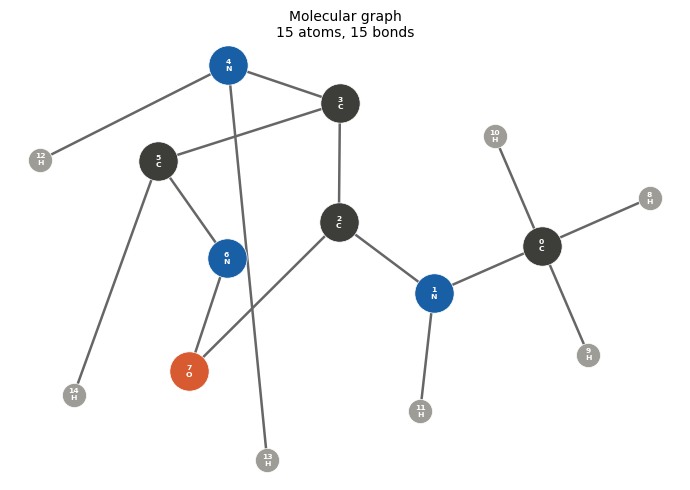


Edge list (bond pairs used for graph construction):
  (0, 1)  C-N  [C1-N2]
  (0, 8)  C-H  [C1-H9]
  (0, 9)  C-H  [C1-H10]
  (0, 10)  C-H  [C1-H11]
  (1, 2)  N-C  [N2-C3]
  (1, 11)  N-H  [N2-H12]
  (2, 3)  C-C  [C3-C4]
  (2, 7)  C-O  [C3-O8]
  (3, 4)  C-N  [C4-N5]
  (3, 5)  C-C  [C4-C6]
  (4, 12)  N-H  [N5-H13]
  (4, 13)  N-H  [N5-H14]
  (5, 6)  C-N  [C6-N7]
  (5, 14)  C-H  [C6-H15]
  (6, 7)  N-O  [N7-O8]


In [8]:
# ══════════════════════════════════════════════════════════════════
# PANEL 1 — Standard 2-D molecular graph (SMILES → RDKit layout)
# Shows: atom nodes, covalent bonds, atom indices
# ══════════════════════════════════════════════════════════════════

def draw_mol_graph(data, ax=None):
    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=(7,5))

    pos    = data['pos']
    syms   = data['pm_syms']
    names  = data['elf_names']
    edges  = data['mg_edges']
    n      = data['n_atoms']

    # edges
    for i,j in edges:
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                color='#666', lw=1.8, zorder=1)

    # nodes
    for i in range(n):
        c = ATOM_COLOR.get(syms[i], '#888')
        s = 800 if syms[i] != 'H' else 300
        ax.scatter(*pos[i], c=c, s=s, zorder=3, edgecolors='white', linewidths=0.5)
        ax.text(*pos[i], f'{i}\n{syms[i]}', ha='center', va='center',
                fontsize=5.5, color='white', zorder=4, fontweight='bold')

    ax.set_title(f"Molecular graph\n{n} atoms, {len(edges)} bonds", fontsize=10)
    ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()

draw_mol_graph(data)
print("\nEdge list (bond pairs used for graph construction):")
for i,j in sorted(data['mg_edges']):
    print(f"  ({i}, {j})  {data['pm_syms'][i]}-{data['pm_syms'][j]}  [{data['elf_names'][i]}-{data['elf_names'][j]}]")


In [9]:
# ── Tensor representation of the molecular graph ──────────────────
edges_sorted = sorted(data['mg_edges'])
# Bidirectional: add both directions
src = [i for i,j in edges_sorted] + [j for i,j in edges_sorted]
dst = [j for i,j in edges_sorted] + [i for i,j in edges_sorted]
edge_index = torch.tensor([src, dst], dtype=torch.long)

x = torch.tensor(data['atom_topo'], dtype=torch.float)   # [N, 13]

print("Molecular graph as tensors:")
print(f"  x (atom features)  : shape {list(x.shape)}  — 13 topology features per atom")
print(f"  edge_index          : shape {list(edge_index.shape)}  — {len(edges_sorted)} undirected bonds → {edge_index.shape[1]} directed edges")
print()
print("edge_index tensor:")
print(f"  src: {edge_index[0].tolist()}")
print(f"  dst: {edge_index[1].tolist()}")
print()
print("x (first 3 atoms):")
feat_names = ["degree","H_nbrs","in_ring",
              "ring3","ring4","ring5","ring6","ring7",
              "is_C","is_F","is_H","is_N","is_O"]
for i in range(min(3, data['n_atoms'])):
    vals = x[i].tolist()
    print(f"  atom {i} ({data['pm_syms'][i]}): {dict(zip(feat_names, [round(v,2) for v in vals]))}")


Molecular graph as tensors:
  x (atom features)  : shape [15, 13]  — 13 topology features per atom
  edge_index          : shape [2, 30]  — 15 undirected bonds → 30 directed edges

edge_index tensor:
  src: [0, 0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 1, 8, 9, 10, 2, 11, 3, 7, 4, 5, 12, 13, 6, 14, 7]
  dst: [1, 8, 9, 10, 2, 11, 3, 7, 4, 5, 12, 13, 6, 14, 7, 0, 0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6]

x (first 3 atoms):
  atom 0 (C): {'degree': 4.0, 'H_nbrs': 3.0, 'in_ring': 0.0, 'ring3': 0.0, 'ring4': 0.0, 'ring5': 0.0, 'ring6': 0.0, 'ring7': 0.0, 'is_C': 1.0, 'is_F': 0.0, 'is_H': 0.0, 'is_N': 0.0, 'is_O': 0.0}
  atom 1 (N): {'degree': 3.0, 'H_nbrs': 1.0, 'in_ring': 0.0, 'ring3': 0.0, 'ring4': 0.0, 'ring5': 0.0, 'ring6': 0.0, 'ring7': 0.0, 'is_C': 0.0, 'is_F': 0.0, 'is_H': 0.0, 'is_N': 1.0, 'is_O': 0.0}
  atom 2 (C): {'degree': 3.0, 'H_nbrs': 0.0, 'in_ring': 1.0, 'ring3': 0.0, 'ring4': 0.0, 'ring5': 1.0, 'ring6': 0.0, 'ring7': 0.0, 'is_C': 1.0, 'is_F': 0.0, 'is_H': 0.0, 'is_N': 0.0,

## 4. ELF CP graph

Valence critical points from the ELF JSON become **nodes** (diamonds), each connected to its two bonded atoms. The topology (which pairs of atoms share a CP) comes entirely from the JSON file.

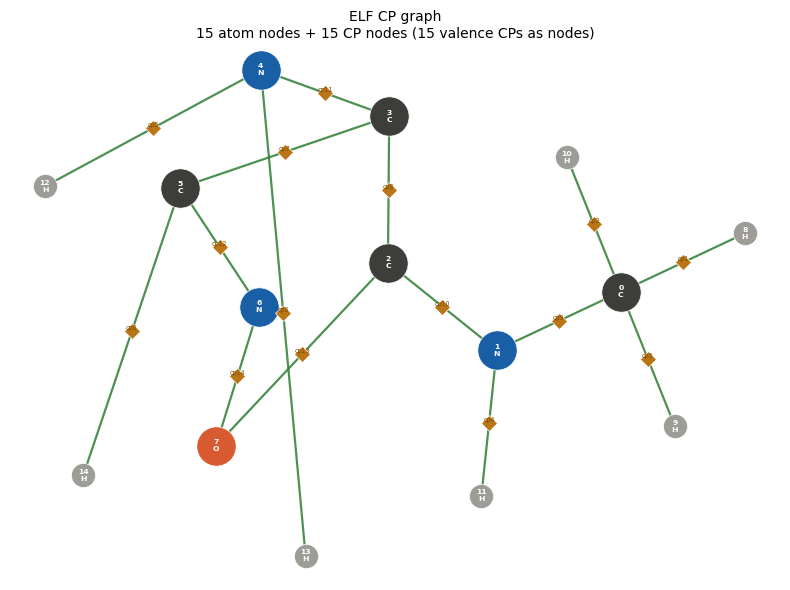


ELF CP summary:
  Bonding CPs (valence, 2 atoms) : 15  → become CP nodes
  Lone-pair CPs (valence, 1 atom): 4  → ignored in graph
  Core CPs                        : 8  → ignored

CP node list (cp_idx | atoms connected | cp type | ELF features):
  cp_idx  atoms       bond?   vol     pop     charge   eta   
  cp  0    (14,5) H-C      ✓real     0.000   0.000    0.000   0.000
  cp  1    (8,0) H-C      ✓real     0.000   0.000    0.000   0.000
  cp  2    (10,0) H-C      ✓real     0.000   0.000    0.000   0.000
  cp  3    (9,0) H-C      ✓real     0.000   0.000    0.000   0.000
  cp  4    (11,1) H-N      ✓real     0.000   0.000    0.000   0.000
  cp  5    (12,4) H-N      ✓real     0.000   0.000    0.000   0.000
  cp  6    (13,4) H-N      ✓real     0.000   0.000    0.000   0.000
  cp  7    (5,3) C-C      ✓real     0.000   0.000    0.000   0.000
  cp  8    (2,3) C-C      ✓real     0.000   0.000    0.000   0.000
  cp  9    (1,0) N-C      ✓real     0.000   0.000    0.000   0.000
  cp 10    (2,1)

In [10]:
# ══════════════════════════════════════════════════════════════════
# PANEL 2 — ELF CP graph
# Nodes: atoms (circles) + valence CPs (diamonds, between atoms)
# Edges: atom–CP–atom (CP is a NODE, not an edge attribute)
# ══════════════════════════════════════════════════════════════════

def draw_elf_graph(data, ax=None):
    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=(8,6))

    pos    = data['pos']
    syms   = data['pm_syms']
    names  = data['elf_names']
    n      = data['n_atoms']
    cps    = [cp for cp in data['elf_cps']
               if cp['type'] == 'valence' and len(cp['atoms']) == 2]

    # Compute CP positions = midpoint of bonded atoms
    cp_pos = {}
    for k, cp in enumerate(cps):
        i, j = cp['atoms']
        cp_pos[k] = (pos[i] + pos[j]) / 2.0

    # Draw atom–CP edges
    for k, cp in enumerate(cps):
        i, j = cp['atoms']
        color = EDGE_COLOR['cov'] if (min(i,j),max(i,j)) in data['mg_edges'] else EDGE_COLOR['noncov']
        # atom i → CP
        ax.plot([pos[i][0], cp_pos[k][0]], [pos[i][1], cp_pos[k][1]],
                color=color, lw=1.6, zorder=1, alpha=0.85)
        # CP → atom j
        ax.plot([cp_pos[k][0], pos[j][0]], [cp_pos[k][1], pos[j][1]],
                color=color, lw=1.6, zorder=1, alpha=0.85)

    # Draw atom nodes
    for i in range(n):
        c = ATOM_COLOR.get(syms[i], '#888')
        s = 800 if syms[i] != 'H' else 300
        ax.scatter(*pos[i], c=c, s=s, zorder=3, edgecolors='white', linewidths=0.5)
        ax.text(*pos[i], f'{i}\n{syms[i]}', ha='center', va='center',
                fontsize=5.5, color='white', zorder=4, fontweight='bold')

    # Draw CP nodes (diamonds)
    for k, cp in enumerate(cps):
        ax.plot(*cp_pos[k], 'D', color=ATOM_COLOR['CP'],
                markersize=8, zorder=5, markeredgecolor='white', markeredgewidth=0.5)
        ax.text(*cp_pos[k], f'cp{k}', ha='center', va='bottom',
                fontsize=4.5, color='#7B4E00', zorder=6)

    n_bond_cps = len(cps)
    ax.set_title(f"ELF CP graph\n{n} atom nodes + {n_bond_cps} CP nodes"
                 f" ({n_bond_cps} valence CPs as nodes)", fontsize=10)
    ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()

draw_elf_graph(data)

# Summary of CP nodes and edges
bond_cps = [cp for cp in data['elf_cps'] if cp['type']=='valence' and len(cp['atoms'])==2]
core_cps = [cp for cp in data['elf_cps'] if cp['type']=='core']
lone_cps = [cp for cp in data['elf_cps'] if cp['type']=='valence' and len(cp['atoms'])==1]
print(f"\nELF CP summary:")
print(f"  Bonding CPs (valence, 2 atoms) : {len(bond_cps)}  → become CP nodes")
print(f"  Lone-pair CPs (valence, 1 atom): {len(lone_cps)}  → ignored in graph")
print(f"  Core CPs                        : {len(core_cps)}  → ignored")
print()
print("CP node list (cp_idx | atoms connected | cp type | ELF features):")
print(f"  {'cp_idx':6}  {'atoms':10}  {'bond?':6}  {'vol':6}  {'pop':6}  {'charge':7}  {'eta':6}")
for k, cp in enumerate(bond_cps):
    i, j = cp['atoms']
    is_real = (min(i,j),max(i,j)) in data['mg_edges']
    print(f"  cp{k:3d}    ({i},{j}) {data['pm_syms'][i]}-{data['pm_syms'][j]:<5}"
          f"  {'✓real' if is_real else '✗noncov':7}"
          f"  {cp['volume']:6.3f}  {cp['pop']:6.3f}  {cp['charge']:7.3f}  {cp['eta']:6.3f}")


In [11]:
# ── ELF CP graph as tensors ────────────────────────────────────────
bond_cps = [cp for cp in data['elf_cps'] if cp['type']=='valence' and len(cp['atoms'])==2]
n_atoms  = data['n_atoms']
n_cps    = len(bond_cps)

# ── Node features ──────────────────────────────────────────────────
# atom.x  : [n_atoms, 13] — topology features (already computed)
atom_x = torch.tensor(data['atom_topo'], dtype=torch.float)

# cp.x    : [n_cps, 5]   — ELF basin features: group, vol, pop, charge, eta
cp_x = torch.tensor(
    [[cp['group'], cp['volume'], cp['pop'], cp['charge'], cp['eta']] for cp in bond_cps],
    dtype=torch.float
)

# global.x: [1, 3]
global_x = torch.tensor(data['global_feat'], dtype=torch.float).unsqueeze(0)

# ── Edge indices ───────────────────────────────────────────────────
# Convention: atom nodes 0..n_atoms-1, CP nodes 0..n_cps-1 (separate index spaces in HeteroData)
# Edges: cp → atom (and reverse)
cp_to_atom_src, cp_to_atom_dst = [], []
for k, cp in enumerate(bond_cps):
    for atom_idx in cp['atoms']:
        cp_to_atom_src.append(k)         # cp index
        cp_to_atom_dst.append(atom_idx)  # atom index

atom_to_cp_src = cp_to_atom_dst[:]
atom_to_cp_dst = cp_to_atom_src[:]

# atom → global (all atoms connect to global node 0)
atom_to_global_src = list(range(n_atoms))
atom_to_global_dst = [0] * n_atoms

# cp → global
cp_to_global_src = list(range(n_cps))
cp_to_global_dst = [0] * n_cps

print("ELF CP graph — HeteroData tensor layout:")
print(f"  atom.x   : {list(atom_x.shape)}   (13 topology features)")
print(f"  cp.x     : {list(cp_x.shape)}    (5 ELF features: group, vol, pop, charge, eta)")
print(f"  global.x : {list(global_x.shape)}   (num_atoms, num_bonds, mol_weight)")
print()
print(f"  (cp, cp_to_atom, atom) edge_index : [2, {len(cp_to_atom_src)}]")
print(f"    src (cp idx) : {cp_to_atom_src}")
print(f"    dst (atom)   : {cp_to_atom_dst}")
print()
print(f"  (atom, atom_to_cp, cp) edge_index : [2, {len(atom_to_cp_src)}]  (reverse)")
print()
print(f"  (atom, atom_to_global, global) edge_index : [2, {len(atom_to_global_src)}]")
print(f"  (cp, cp_to_global, global) edge_index     : [2, {len(cp_to_global_src)}]")
print()
print("cp.x first 3 rows (group | volume | population | charge | eta):")
for k in range(min(3, n_cps)):
    cp = bond_cps[k]
    i, j = cp['atoms']
    print(f"  cp{k} ({data['pm_syms'][i]}-{data['pm_syms'][j]}): {cp_x[k].tolist()}")


ELF CP graph — HeteroData tensor layout:
  atom.x   : [15, 13]   (13 topology features)
  cp.x     : [15, 5]    (5 ELF features: group, vol, pop, charge, eta)
  global.x : [1, 3]   (num_atoms, num_bonds, mol_weight)

  (cp, cp_to_atom, atom) edge_index : [2, 30]
    src (cp idx) : [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14]
    dst (atom)   : [14, 5, 8, 0, 10, 0, 9, 0, 11, 1, 12, 4, 13, 4, 5, 3, 2, 3, 1, 0, 2, 1, 3, 4, 6, 5, 7, 2, 7, 6]

  (atom, atom_to_cp, cp) edge_index : [2, 30]  (reverse)

  (atom, atom_to_global, global) edge_index : [2, 15]
  (cp, cp_to_global, global) edge_index     : [2, 15]

cp.x first 3 rows (group | volume | population | charge | eta):
  cp0 (H-C): [-3.0, 0.0, 0.0, 0.0, 0.0]
  cp1 (H-C): [-3.0, 0.0, 0.0, 0.0, 0.0]
  cp2 (H-C): [-3.0, 0.0, 0.0, 0.0, 0.0]


## 5. SOTA QTAIM graph

Edges come from `extra_feat_bond_indices_qtaim` in the PKL. Each QTAIM bond critical point becomes an **edge** (not a node), with 19 QTAIM features as edge attributes.

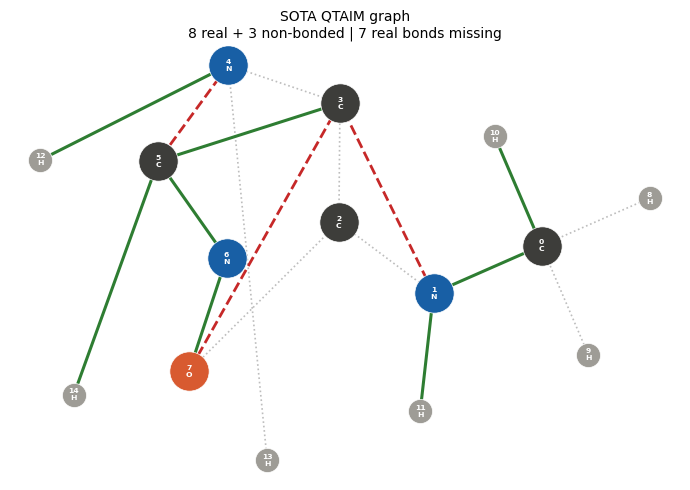


QTAIM edge list (from PKL extra_feat_bond_indices_qtaim):
  (0,1)  C-N  ✓ real bond
  (0,10)  C-H  ✓ real bond
  (1,3)  N-C  ✗ non-bonded BCP
  (1,11)  N-H  ✓ real bond
  (3,5)  C-C  ✓ real bond
  (3,7)  C-O  ✗ non-bonded BCP
  (4,5)  N-C  ✗ non-bonded BCP
  (4,12)  N-H  ✓ real bond
  (5,6)  C-N  ✓ real bond
  (5,14)  C-H  ✓ real bond
  (6,7)  N-O  ✓ real bond

Real bonds missing from QTAIM (7):
  (0,8)  C-H
  (0,9)  C-H
  (1,2)  N-C
  (2,3)  C-C
  (2,7)  C-O
  (3,4)  C-N
  (4,13)  N-H


In [12]:
# ══════════════════════════════════════════════════════════════════
# PANEL 3 — SOTA QTAIM graph (from PKL)
# Standard atom-bond-global hetero graph
# QTAIM bond critical points define which edges exist
# Green = QTAIM edge that matches real covalent bond
# Red   = QTAIM non-bonded through-space interaction
# Dotted grey = real bond MISSING from QTAIM
# ══════════════════════════════════════════════════════════════════

def draw_qtaim_graph(data, ax=None):
    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=(7,5))

    pos         = data['pos']
    syms        = data['pm_syms']
    n           = data['n_atoms']
    mg_edges    = data['mg_edges']
    qtaim_edges = data['qtaim_edges']

    qtaim_real    = [e for e in qtaim_edges if e in mg_edges]
    qtaim_noncov  = [e for e in qtaim_edges if e not in mg_edges]
    mg_missing    = [e for e in mg_edges    if e not in qtaim_edges]

    for i,j in mg_missing:
        ax.plot([pos[i][0],pos[j][0]],[pos[i][1],pos[j][1]],
                color=EDGE_COLOR['missing'], lw=1.2, ls='dotted', zorder=1)
    for i,j in qtaim_real:
        ax.plot([pos[i][0],pos[j][0]],[pos[i][1],pos[j][1]],
                color=EDGE_COLOR['cov'], lw=2.2, zorder=2)
    for i,j in qtaim_noncov:
        ax.plot([pos[i][0],pos[j][0]],[pos[i][1],pos[j][1]],
                color=EDGE_COLOR['noncov'], lw=2.0, ls='--', zorder=2)

    for i in range(n):
        c = ATOM_COLOR.get(syms[i], '#888')
        s = 800 if syms[i] != 'H' else 300
        ax.scatter(*pos[i], c=c, s=s, zorder=3, edgecolors='white', linewidths=0.5)
        ax.text(*pos[i], f'{i}\n{syms[i]}', ha='center', va='center',
                fontsize=5.5, color='white', zorder=4, fontweight='bold')

    ax.set_title(
        f"SOTA QTAIM graph\n"
        f"{len(qtaim_real)} real + {len(qtaim_noncov)} non-bonded | "
        f"{len(mg_missing)} real bonds missing", fontsize=10)
    ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()

draw_qtaim_graph(data)

print("\nQTAIM edge list (from PKL extra_feat_bond_indices_qtaim):")
mg = data['mg_edges']; qtaim = data['qtaim_edges']
for i,j in sorted(qtaim):
    tag = '✓ real bond' if (i,j) in mg else '✗ non-bonded BCP'
    print(f"  ({i},{j})  {data['pm_syms'][i]}-{data['pm_syms'][j]}  {tag}")
print(f"\nReal bonds missing from QTAIM ({sum(1 for e in mg if e not in qtaim)}):")
for i,j in sorted(e for e in mg if e not in qtaim):
    print(f"  ({i},{j})  {data['pm_syms'][i]}-{data['pm_syms'][j]}")


In [13]:
# ── QTAIM graph as tensors (atom-bond-global HeteroData) ───────────
n_atoms  = data['n_atoms']
qtaim_edges_sorted = sorted(data['qtaim_edges'])
n_bonds  = len(qtaim_edges_sorted)

# ── atom.x [n_atoms, 13] ──────────────────────────────────────────
atom_x = torch.tensor(data['atom_topo'], dtype=torch.float)

# ── bond.x [n_bonds, 19] — QTAIM bond features ───────────────────
bond_x_rows = []
for (i,j) in qtaim_edges_sorted:
    key = (min(i,j), max(i,j))
    feat = data['bond_feat_lookup'].get(key, np.zeros(len(BOND_QTAIM_COLS)))
    bond_x_rows.append(feat)
bond_x = torch.tensor(np.stack(bond_x_rows), dtype=torch.float)

# ── global.x [1, 3] ───────────────────────────────────────────────
global_x = torch.tensor(data['global_feat'], dtype=torch.float).unsqueeze(0)

# ── Edge indices ───────────────────────────────────────────────────
# atom ↔ bond (each bond edge connects to 2 atoms)
bond_to_atom_src, bond_to_atom_dst = [], []
for k, (i,j) in enumerate(qtaim_edges_sorted):
    bond_to_atom_src += [k, k]    # bond k connects to both endpoints
    bond_to_atom_dst += [i, j]

atom_to_bond_src = bond_to_atom_dst[:]
atom_to_bond_dst = bond_to_atom_src[:]

atom_to_global_src = list(range(n_atoms))
atom_to_global_dst = [0] * n_atoms
bond_to_global_src = list(range(n_bonds))
bond_to_global_dst = [0] * n_bonds

print("QTAIM graph — HeteroData tensor layout:")
print(f"  atom.x   : {list(atom_x.shape)}   (13 topology features)")
print(f"  bond.x   : {list(bond_x.shape)}   (19 QTAIM bond features)")
print(f"  global.x : {list(global_x.shape)}   (num_atoms, num_bonds, mol_weight)")
print()
print(f"  (bond, bond_to_atom, atom) edge_index : [2, {len(bond_to_atom_src)}]")
print(f"    src (bond idx): {bond_to_atom_src}")
print(f"    dst (atom idx): {bond_to_atom_dst}")
print()
print(f"  (atom, atom_to_bond, bond) edge_index : [2, {len(atom_to_bond_src)}]  (reverse)")
print()
print(f"  (atom, to_global, global) edge_index  : [2, {len(atom_to_global_src)}]")
print(f"  (bond, to_global, global) edge_index  : [2, {len(bond_to_global_src)}]")
print()
print(f"Bond edges used (from QTAIM bond critical points):")
for k, (i,j) in enumerate(qtaim_edges_sorted):
    key = (min(i,j),max(i,j))
    tag = '✓' if key in data['mg_edges'] else '✗ non-bonded'
    feats = bond_x[k][:4].tolist()  # first 4 features as preview
    print(f"  bond{k:2d} ({i},{j}) {data['pm_syms'][i]}-{data['pm_syms'][j]} {tag}  "
          f"feat[:4]={[round(v,4) for v in feats]}")
print()
print("bond.x column names (19 QTAIM bond features):")
for k, name in enumerate(BOND_QTAIM_COLS):
    short = name.replace('extra_feat_bond_','')
    print(f"  [{k:2d}] {short}")


QTAIM graph — HeteroData tensor layout:
  atom.x   : [15, 13]   (13 topology features)
  bond.x   : [11, 19]   (19 QTAIM bond features)
  global.x : [1, 3]   (num_atoms, num_bonds, mol_weight)

  (bond, bond_to_atom, atom) edge_index : [2, 22]
    src (bond idx): [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10]
    dst (atom idx): [0, 1, 0, 10, 1, 3, 1, 11, 3, 5, 3, 7, 4, 5, 4, 12, 5, 6, 5, 14, 6, 7]

  (atom, atom_to_bond, bond) edge_index : [2, 22]  (reverse)

  (atom, to_global, global) edge_index  : [2, 15]
  (bond, to_global, global) edge_index  : [2, 11]

Bond edges used (from QTAIM bond critical points):
  bond 0 (0,1) C-N ✓  feat[:4]=[0.3169, -0.3169, -0.7063, 0.8236]
  bond 1 (0,10) C-H ✓  feat[:4]=[0.3, -0.3, -1.0383, 0.9863]
  bond 2 (1,3) N-C ✗ non-bonded  feat[:4]=[0.4881, -0.4881, -1.0615, 0.7952]
  bond 3 (1,11) N-H ✓  feat[:4]=[0.4429, -0.4429, -1.574, 0.9889]
  bond 4 (3,5) C-C ✓  feat[:4]=[0.3198, -0.3198, -0.7952, 0.9238]
  bond 5 (3,7) C-O ✗ non-

## 6. Side-by-side comparison

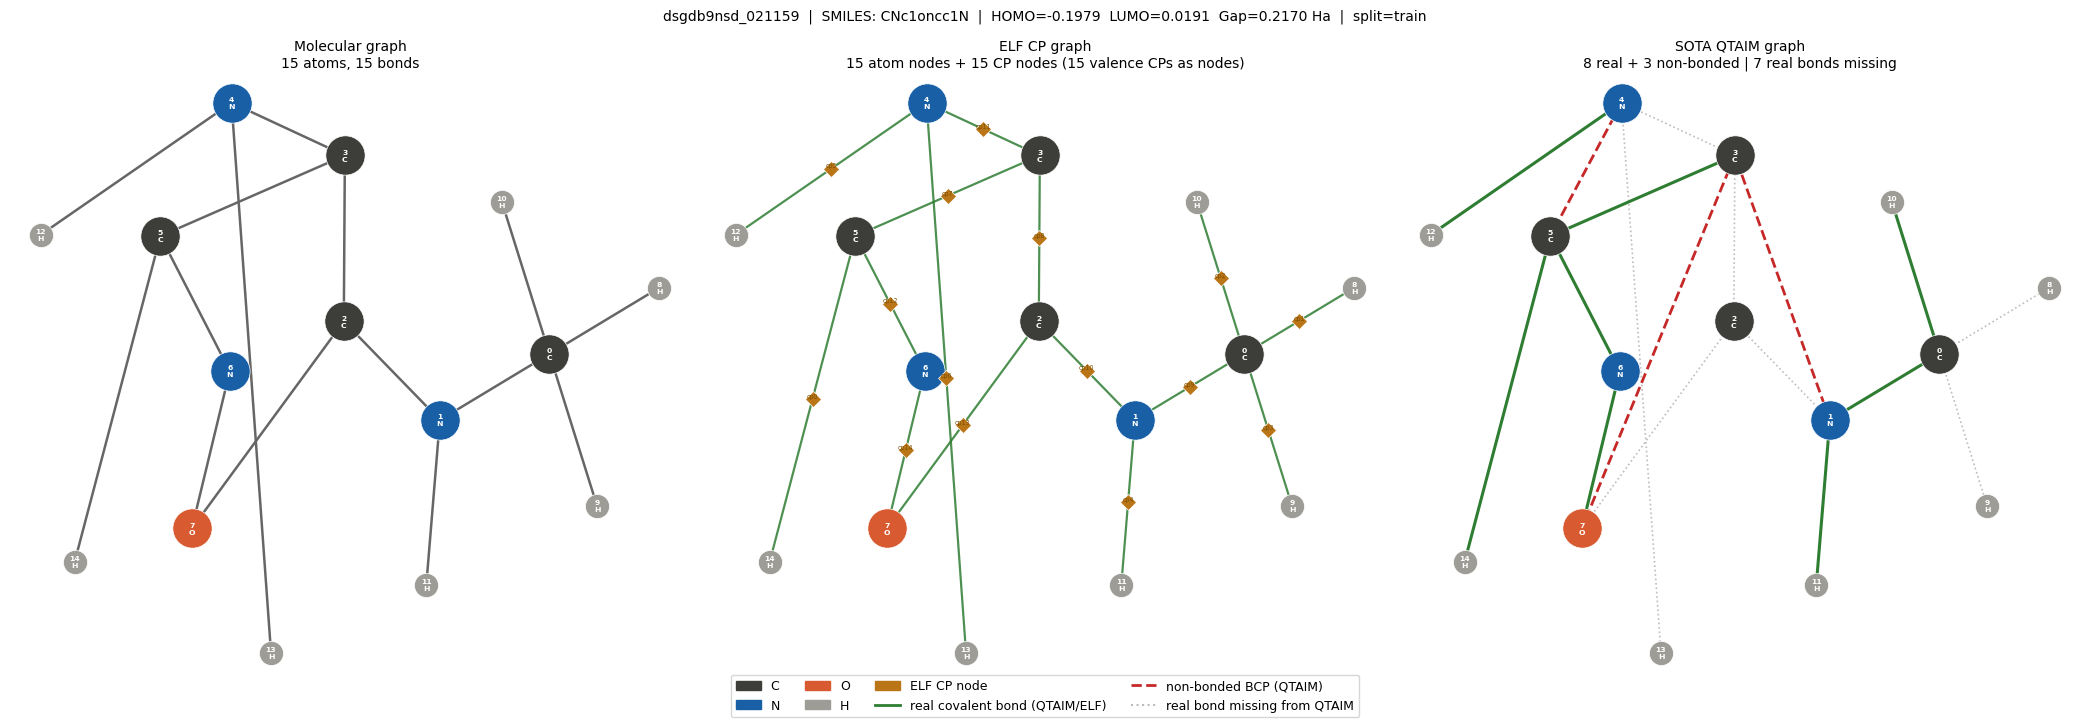

In [14]:
# ══════════════════════════════════════════════════════════════════
# SIDE-BY-SIDE: all three graphs on one figure
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

draw_mol_graph(data, ax=axes[0])
draw_elf_graph(data, ax=axes[1])
draw_qtaim_graph(data, ax=axes[2])

# shared legend
legend_elements = [
    mpatches.Patch(color=ATOM_COLOR['C'],  label='C'),
    mpatches.Patch(color=ATOM_COLOR['N'],  label='N'),
    mpatches.Patch(color=ATOM_COLOR['O'],  label='O'),
    mpatches.Patch(color=ATOM_COLOR['H'],  label='H'),
    mpatches.Patch(color=ATOM_COLOR['CP'], label='ELF CP node'),
    Line2D([0],[0], color=EDGE_COLOR['cov'],     lw=2, label='real covalent bond (QTAIM/ELF)'),
    Line2D([0],[0], color=EDGE_COLOR['noncov'],  lw=2, ls='--', label='non-bonded BCP (QTAIM)'),
    Line2D([0],[0], color=EDGE_COLOR['missing'], lw=1.5, ls='dotted', label='real bond missing from QTAIM'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f"{data['mol_id']}  |  SMILES: {data['smiles']}  |  "
    f"HOMO={data['homo']:.4f}  LUMO={data['lumo']:.4f}  Gap={data['gap']:.4f} Ha  "
    f"|  split={data['split']}",
    fontsize=10)
fig.tight_layout()
plt.show()


In [15]:
# ══════════════════════════════════════════════════════════════════
# COMPARISON TABLE: what each graph looks like as a PyG HeteroData
# ══════════════════════════════════════════════════════════════════

bond_cps = [cp for cp in data['elf_cps'] if cp['type']=='valence' and len(cp['atoms'])==2]
n_atoms  = data['n_atoms']
n_cps    = len(bond_cps)
n_qtaim  = len(data['qtaim_edges'])

print("=" * 70)
print(f"  Graph comparison — {data['mol_id']}  ({n_atoms} atoms)")
print("=" * 70)
print(f"\n{'':30} {'Standard':>12}  {'ELF CP':>12}  {'QTAIM':>12}")
print(f"  {'─'*66}")
print(f"  {'Atom nodes':<28} {n_atoms:>12}  {n_atoms:>12}  {n_atoms:>12}")
print(f"  {'CP / bond nodes':<28} {0:>12}  {n_cps:>12}  {n_qtaim:>12}")
print(f"  {'Global node':<28} {0:>12}  {1:>12}  {1:>12}")
print(f"  {'Atom feature dim':<28} {13:>12}  {13:>12}  {13:>12}")
print(f"  {'CP/bond feature dim':<28} {'—':>12}  {'5 (ELF)':>12}  {'19 (QTAIM)':>12}")
print(f"  {'Edge types':<28} {'atom-atom':>12}  {'atom-CP-atom':>12}  {'atom-bond-atom':>14}")
print(f"  {'Edges based on':<28} {'mol graph':>12}  {'ELF basins':>12}  {'QTAIM BCPs':>12}")
print(f"  {'─'*66}")
print(f"\n  Real bonds: {len(data['mg_edges'])}")
print(f"  ELF bonding CPs (= real bonds): {sum(1 for cp in bond_cps if (min(cp['atoms'][0],cp['atoms'][1]),max(cp['atoms'][0],cp['atoms'][1])) in data['mg_edges'])}")
print(f"  QTAIM bonds that match real bonds: {sum(1 for e in data['qtaim_edges'] if e in data['mg_edges'])}")
print(f"  QTAIM non-bonded BCPs: {sum(1 for e in data['qtaim_edges'] if e not in data['mg_edges'])}")
print(f"  Real bonds missing from QTAIM: {sum(1 for e in data['mg_edges'] if e not in data['qtaim_edges'])}")


  Graph comparison — dsgdb9nsd_021159  (15 atoms)

                                   Standard        ELF CP         QTAIM
  ──────────────────────────────────────────────────────────────────
  Atom nodes                             15            15            15
  CP / bond nodes                         0            15            11
  Global node                             0             1             1
  Atom feature dim                       13            13            13
  CP/bond feature dim                     —       5 (ELF)    19 (QTAIM)
  Edge types                      atom-atom  atom-CP-atom  atom-bond-atom
  Edges based on                  mol graph    ELF basins    QTAIM BCPs
  ──────────────────────────────────────────────────────────────────

  Real bonds: 15
  ELF bonding CPs (= real bonds): 15
  QTAIM bonds that match real bonds: 8
  QTAIM non-bonded BCPs: 3
  Real bonds missing from QTAIM: 7
